# Part C : Analytics (Insights + KPIs)
 1. Marketing Performance Diagnosis
 2. KPI Trends (Daily / Weekly)
 3. Segment Deep Dive
 4. Marketing Investigation Table

In [2]:
# Load Curated Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
# Load your ETL outputs:

fact_sessions = pd.read_csv("../data/fact_sessions.csv")
fact_campaign = pd.read_csv("../data/fact_campaign_daily.csv")
fact_channel = pd.read_csv("../data/fact_channel_daily.csv")


In [4]:
# Convert dates:
fact_campaign["date"] = pd.to_datetime(fact_campaign["date"])
fact_channel["date"] = pd.to_datetime(fact_channel["date"])
fact_sessions["session_ts"] = pd.to_datetime(fact_sessions["session_ts"])


## 1) Marketing Performance Diagnosis

In [5]:
# Channel Performance

channel_perf = fact_channel.groupby("channel").agg(
    spend=("total_spend","sum"),
    revenue=("attributed_revenue","sum"),
    orders=("attributed_orders","sum")
).reset_index()

channel_perf["ROAS"] = channel_perf["revenue"] / channel_perf["spend"]
channel_perf["CAC"] = channel_perf["spend"] / channel_perf["orders"]

channel_perf.sort_values("revenue",ascending=False)

,channel,spend,revenue,orders,ROAS,CAC
4,search,34333235.87,45558637.31,6681.0,1.326954,5138.936667
0,email,3813282.01,19250984.14,3003.0,5.048403,1269.824179
2,paid_social,28586495.57,19095173.73,3203.0,0.667979,8924.912760
1,organic,958408.31,12400693.30,1999.0,12.938842,479.443877
3,referral,6669377.76,8748854.47,1307.0,1.311795,5102.813894


In [6]:
# Top 5 Campaigns by Spend

top_spend = fact_campaign.groupby("campaign_id").agg(
    spend=("spend","sum"),
    revenue=("attributed_revenue","sum")
).reset_index()

top_spend.sort_values("spend",ascending=False).head(5)

,campaign_id,spend,revenue
0,C001,4369244.94,5479447.65
1,C002,4328266.00,6183917.98
5,C006,4327050.43,5750836.33
7,C008,4320160.64,5551850.62
3,C004,4288198.93,5175585.24


In [7]:
# Campaigns by Revenue

top_revenue = fact_campaign.groupby("campaign_id").agg(
    spend=("spend","sum"),
    revenue=("attributed_revenue","sum")
).reset_index()

top_revenue.sort_values("revenue",ascending=False).head(5)

,campaign_id,spend,revenue
1,C002,4328266.00,6183917.98
6,C007,4285939.27,6042963.38
5,C006,4327050.43,5750836.33
2,C003,4272019.15,5705047.59
4,C005,4142356.51,5668988.52


In [8]:
# Wasted Spend Candidates

campaign_perf = fact_campaign.groupby("campaign_id").agg(
    spend=("spend","sum"),
    revenue=("attributed_revenue","sum")
).reset_index()

campaign_perf["ROAS"] = campaign_perf["revenue"]/campaign_perf["spend"]

wasted = campaign_perf.sort_values("ROAS").head(5)

wasted

,campaign_id,spend,revenue,ROAS
15,C016,3624551.23,2249073.35,0.620511
9,C010,3587417.03,2251008.46,0.627473
10,C011,3606207.61,2379154.14,0.659739
13,C014,3587281.51,2370560.35,0.660824
12,C013,3529354.04,2429852.10,0.688469


## 2) KPI Trends (Daily/Weekly)

In [9]:
# Add week column.

fact_channel["week"] = fact_channel["date"].dt.isocalendar().week

In [10]:
# Aggregate weekly.

weekly = fact_channel.groupby(["week","channel"]).agg(
    spend=("total_spend","sum"),
    revenue=("attributed_revenue","sum"),
    orders=("attributed_orders","sum")
).reset_index()

In [11]:
# Calculate KPIs

weekly["ROAS"] = weekly["revenue"] / weekly["spend"]
weekly["CAC"] = weekly["spend"] / weekly["orders"]

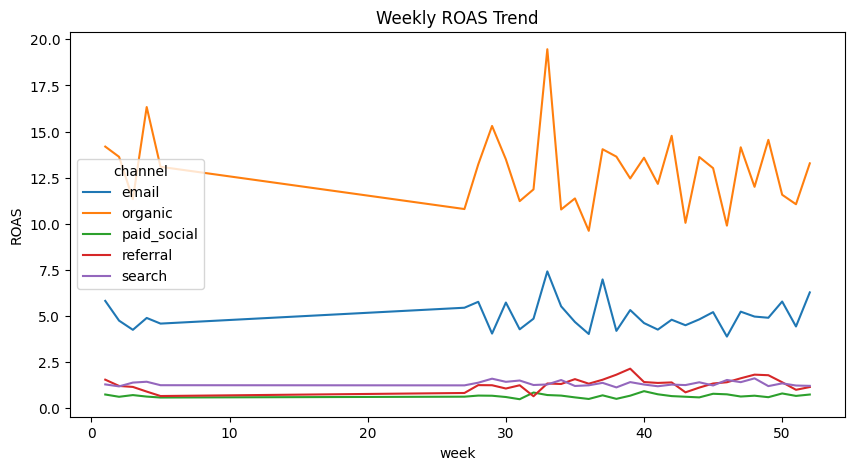

In [12]:
# Plot KPI Trends

plt.figure(figsize=(10,5))
sns.lineplot(data=weekly,x="week",y="ROAS",hue="channel")
plt.title("Weekly ROAS Trend")
plt.show()

## 3) Segment Deep Dive (Mandatory)

In [13]:
# Channel × Device Performance

segment_device = fact_sessions.groupby(["channel","device"]).agg(
    sessions=("session_id","count"),
    orders=("purchase_flag","sum"),
    revenue=("net_amount","sum")
).reset_index()

segment_device["conversion_rate"] = segment_device["orders"] / segment_device["sessions"]

segment_device.sort_values("conversion_rate",ascending=False)

,channel,device,sessions,orders,revenue,conversion_rate
1,email,web,39900,1807,11406411.65,0.045288
0,email,mobile,29243,1166,7641560.00,0.039873
9,search,web,128863,4215,28613225.49,0.032709
7,referral,web,26060,834,5651264.37,0.032003
8,search,mobile,93563,2413,16598981.78,0.025790
6,referral,mobile,19002,462,3045716.72,0.024313
5,paid_social,web,87547,1736,10257567.79,0.019829
3,organic,web,54683,1077,6673280.85,0.019695
2,organic,mobile,66599,908,5648668.71,0.013634
4,paid_social,mobile,107756,1443,8688355.68,0.013391


In [14]:
# New vs Returning Users

segment_users = fact_sessions.groupby("is_new_user").agg(
    sessions=("session_id","count"),
    orders=("purchase_flag","sum"),
    revenue=("net_amount","sum")
).reset_index()

segment_users["conversion_rate"] = segment_users["orders"] / segment_users["sessions"]

segment_users

,is_new_user,sessions,orders,revenue,conversion_rate
0,0,656021,16144,1.047738e+08,0.024609
1,1,1799,49,2.805383e+05,0.027237


In [15]:
# City Tier Analysis

city_perf = fact_sessions.groupby("city_tier").agg(
    sessions=("session_id","count"),
    orders=("purchase_flag","sum"),
    revenue=("net_amount","sum")
).reset_index()

city_perf["conversion_rate"] = city_perf["orders"] / city_perf["sessions"]

city_perf.sort_values("conversion_rate",ascending=False)

,city_tier,sessions,orders,revenue,conversion_rate
0,1.0,139871,3542,23149870.05,0.025323
2,3.0,136798,3405,22032556.41,0.024891
1,2.0,275741,6753,43813830.36,0.024490


In [16]:
# Customer Segment

segment_perf = fact_sessions.groupby("segment").agg(
    sessions=("session_id","count"),
    orders=("purchase_flag","sum"),
    revenue=("net_amount","sum")
).reset_index()

segment_perf["conversion_rate"] = segment_perf["orders"] / segment_perf["sessions"]

segment_perf.sort_values("conversion_rate",ascending=False)

,segment,sessions,orders,revenue,conversion_rate
0,premium,85325,3033,19263191.26,0.035546
1,regular,259933,6587,42719415.19,0.025341
2,value,207152,4080,27013650.37,0.019696


In [17]:
# Product Category Analysis

order_items = pd.read_csv("../data_raw/order_items.csv")
products = pd.read_json("../data_raw/products.json")

In [18]:
order_prod = order_items.merge(products,on="product_id")

category_perf = order_prod.groupby("category").agg(
    revenue=("price","sum"),
    items_sold=("product_id","count")
).reset_index()

category_perf.sort_values("revenue",ascending=False)

,category,revenue,items_sold
1,Books,11622269.70,7810
3,Fashion,10790454.92,7712
5,Sports,9693088.80,7760
4,Home,9679222.12,6899
0,Beauty,7122678.97,5441
2,Electronics,5071847.87,4834


# Part D — Attribution Analysis (Must-have)

In [20]:
# 1. Load curated outputs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fact_sessions = pd.read_csv("../data/fact_sessions.csv")
fact_campaign = pd.read_csv("../data/fact_campaign_daily.csv")
fact_channel = pd.read_csv("../data/fact_channel_daily.csv")

fact_sessions["session_ts"] = pd.to_datetime(fact_sessions["session_ts"])
fact_campaign["date"] = pd.to_datetime(fact_campaign["date"])
fact_channel["date"] = pd.to_datetime(fact_channel["date"])

In [21]:
# 2. Attributed revenue and orders by channel

attrib_channel = fact_channel.groupby("channel").agg(
    spend=("total_spend", "sum"),
    attributed_orders=("attributed_orders", "sum"),
    attributed_revenue=("attributed_revenue", "sum")
).reset_index()

attrib_channel["attributed_roas"] = attrib_channel["attributed_revenue"] / attrib_channel["spend"]
attrib_channel["cac_proxy"] = attrib_channel["spend"] / attrib_channel["attributed_orders"]

attrib_channel = attrib_channel.sort_values("attributed_revenue", ascending=False)
attrib_channel

,channel,spend,attributed_orders,attributed_revenue,attributed_roas,cac_proxy
4,search,34333235.87,6681.0,45558637.31,1.326954,5138.936667
0,email,3813282.01,3003.0,19250984.14,5.048403,1269.824179
2,paid_social,28586495.57,3203.0,19095173.73,0.667979,8924.912760
1,organic,958408.31,1999.0,12400693.30,12.938842,479.443877
3,referral,6669377.76,1307.0,8748854.47,1.311795,5102.813894


In [22]:
# Attributed revenue and orders by campaign
attrib_campaign = fact_campaign.groupby(
    ["campaign_id", "campaign_name", "channel", "objective"]
).agg(
    spend=("spend", "sum"),
    attributed_sessions=("attributed_sessions", "sum"),
    attributed_orders=("attributed_orders", "sum"),
    attributed_revenue=("attributed_revenue", "sum")
).reset_index()

attrib_campaign["attributed_roas"] = attrib_campaign["attributed_revenue"] / attrib_campaign["spend"]
attrib_campaign["cac_proxy"] = attrib_campaign["spend"] / attrib_campaign["attributed_orders"].replace(0, np.nan)

attrib_campaign = attrib_campaign.sort_values("attributed_revenue", ascending=False)
attrib_campaign.head(10)

,campaign_id,campaign_name,channel,objective,spend,attributed_sessions,attributed_orders,attributed_revenue,attributed_roas,cac_proxy
1,C002,search_camp_002,search,acquisition,4328266.00,28463.0,867.0,6183917.98,1.428729,4992.232987
6,C007,search_camp_007,search,acquisition,4285939.27,27926.0,853.0,6042963.38,1.409951,5024.547796
5,C006,search_camp_006,search,acquisition,4327050.43,27885.0,848.0,5750836.33,1.329043,5102.653809
2,C003,search_camp_003,search,acquisition,4272019.15,27981.0,837.0,5705047.59,1.335445,5103.965532
4,C005,search_camp_005,search,acquisition,4142356.51,27771.0,851.0,5668988.52,1.368542,4867.633972
7,C008,search_camp_008,search,acquisition,4320160.64,28154.0,828.0,5551850.62,1.285103,5217.585314
0,C001,search_camp_001,search,acquisition,4369244.94,27904.0,809.0,5479447.65,1.254095,5400.797206
3,C004,search_camp_004,search,acquisition,4288198.93,27919.0,788.0,5175585.24,1.206937,5441.876815
16,C017,email_camp_017,email,retention,461551.37,8981.0,397.0,2631433.59,5.701280,1162.597909
19,C020,email_camp_020,email,retention,476365.76,8535.0,398.0,2545941.38,5.344510,1196.898894


In [24]:
# Blended ROAS by channel

blended_channel = fact_channel.groupby("channel").agg(
    spend=("total_spend", "sum"),
    revenue=("attributed_revenue", "sum")
).reset_index()

blended_channel["blended_roas"] = blended_channel["revenue"] / blended_channel["spend"]
blended_channel

,channel,spend,revenue,blended_roas
0,email,3813282.01,19250984.14,5.048403
1,organic,958408.31,12400693.30,12.938842
2,paid_social,28586495.57,19095173.73,0.667979
3,referral,6669377.76,8748854.47,1.311795
4,search,34333235.87,45558637.31,1.326954


In [25]:
# Better comparison: channel revenue share vs spend share

channel_compare = attrib_channel.copy()

total_spend = channel_compare["spend"].sum()
total_revenue = channel_compare["attributed_revenue"].sum()

channel_compare["spend_share_pct"] = 100 * channel_compare["spend"] / total_spend
channel_compare["revenue_share_pct"] = 100 * channel_compare["attributed_revenue"] / total_revenue
channel_compare["share_gap_pct"] = channel_compare["revenue_share_pct"] - channel_compare["spend_share_pct"]

channel_compare.sort_values("share_gap_pct", ascending=False)

,channel,spend,attributed_orders,attributed_revenue,attributed_roas,cac_proxy,spend_share_pct,revenue_share_pct,share_gap_pct
0,email,3813282.01,3003.0,19250984.14,5.048403,1269.824179,5.128081,18.324787,13.196706
1,organic,958408.31,1999.0,12400693.30,12.938842,479.443877,1.288862,11.804075,10.515213
3,referral,6669377.76,1307.0,8748854.47,1.311795,5102.813894,8.968943,8.327932,-0.641011
4,search,34333235.87,6681.0,45558637.31,1.326954,5138.936667,46.171149,43.366734,-2.804416
2,paid_social,28586495.57,3203.0,19095173.73,0.667979,8924.912760,38.442964,18.176472,-20.266492


In [26]:
# Top and bottom campaigns by attributed ROAS

top_campaign_roas = attrib_campaign.sort_values("attributed_roas", ascending=False).head(10)
bottom_campaign_roas = attrib_campaign.sort_values("attributed_roas", ascending=True).head(10)

top_campaign_roas
bottom_campaign_roas

,campaign_id,campaign_name,channel,objective,spend,attributed_sessions,attributed_orders,attributed_revenue,attributed_roas,cac_proxy
15,C016,paid_social_camp_016,paid_social,acquisition,3624551.23,24403.0,395.0,2249073.35,0.620511,9176.079063
9,C010,paid_social_camp_010,paid_social,acquisition,3587417.03,25165.0,398.0,2251008.46,0.627473,9013.610628
10,C011,paid_social_camp_011,paid_social,acquisition,3606207.61,24664.0,398.0,2379154.14,0.659739,9060.823141
13,C014,paid_social_camp_014,paid_social,acquisition,3587281.51,24342.0,403.0,2370560.35,0.660824,8901.442953
12,C013,paid_social_camp_013,paid_social,acquisition,3529354.04,24984.0,412.0,2429852.10,0.688469,8566.393301
14,C015,paid_social_camp_015,paid_social,acquisition,3526893.92,23824.0,405.0,2434463.52,0.690257,8708.380049
11,C012,paid_social_camp_012,paid_social,acquisition,3552087.57,24702.0,378.0,2460848.04,0.692789,9397.057063
8,C009,paid_social_camp_009,paid_social,acquisition,3572702.66,24594.0,414.0,2520213.77,0.705408,8629.716570
29,C030,referral_camp_030,referral,acquisition,820740.61,5389.0,139.0,823035.38,1.002796,5904.608705
27,C028,referral_camp_028,referral,acquisition,841543.46,5482.0,157.0,992213.90,1.179041,5360.149427


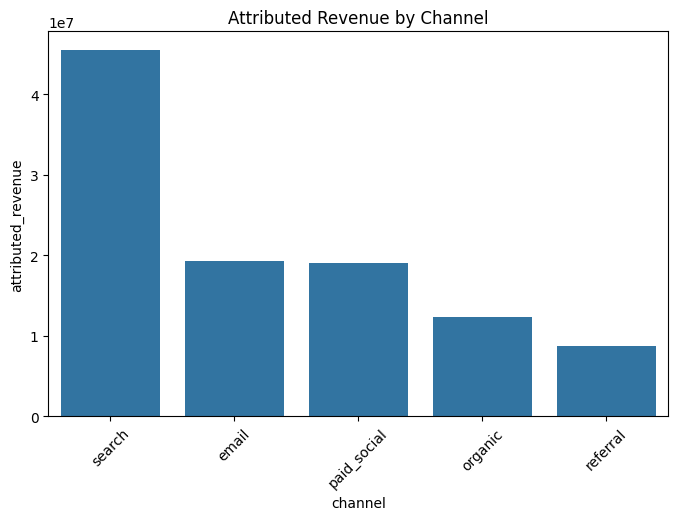

In [27]:
# Visualize attributed revenue by channel

plt.figure(figsize=(8,5))
sns.barplot(data=attrib_channel, x="channel", y="attributed_revenue")
plt.title("Attributed Revenue by Channel")
plt.xticks(rotation=45)
plt.show()

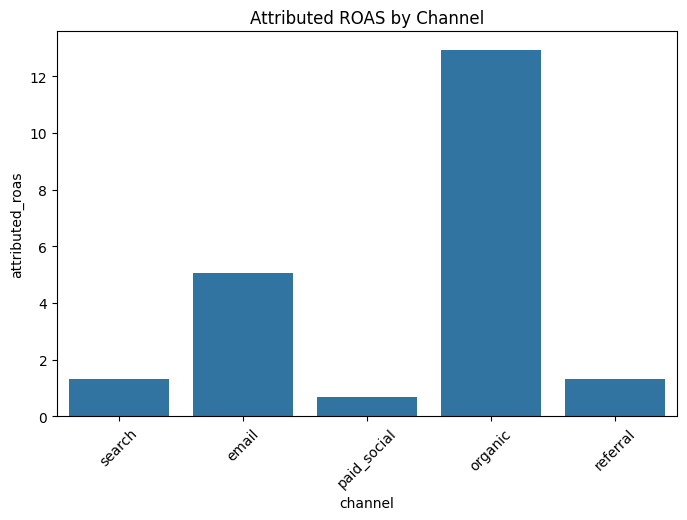

In [28]:
# Visualize attributed ROAS by channel

plt.figure(figsize=(8,5))
sns.barplot(data=attrib_channel, x="channel", y="attributed_roas")
plt.title("Attributed ROAS by Channel")
plt.xticks(rotation=45)
plt.show()


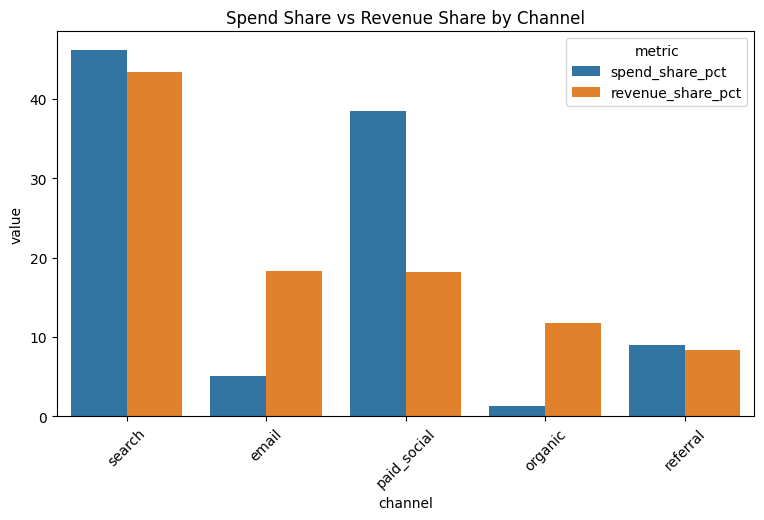

In [29]:
# Visualize spend share vs revenue share

compare_plot = channel_compare.melt(
    id_vars="channel",
    value_vars=["spend_share_pct", "revenue_share_pct"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(9,5))
sns.barplot(data=compare_plot, x="channel", y="value", hue="metric")
plt.title("Spend Share vs Revenue Share by Channel")
plt.xticks(rotation=45)
plt.show()

1. Email shows the highest ROAS and strong efficiency despite low spend.

2. Paid Social consumes significant spend but contributes lower revenue share, indicating inefficiency.

3. Search drives the largest share of total revenue and remains the key scale channel.

4. Revenue is concentrated in a few high-performing campaigns.

5. Channels with higher spend share than revenue share should be reviewed for optimization.